# EX3: Guided Microwave (Uwave) Propagation

## Session 1: Mar 3rd, 2026

#### 1.1 Background theory

- When speed of electronic signals transition from kilohertz to gigahertz range (microwaves and beyond), things take an interesting turn
- With kilohertz signals, voltage stays uniform along the length of the entire wave guide 
    - No measureable phase shift from one of guide to another 
- With gigahertz signals, voltage varies periodically along guide
    - Wavelength is typically a lot shorter (in the centimeter range vs. kilometres)
    - Sinusoidal signal acts like a standing wave
    - If not adequated terminated, nodes and atinodes will be created
- Another thing to note is that rectangular waveguides have a cutoff frequency to which waves cannot propagate at all (voltage would just decay exponentially)
- The general expressionfor an electric field takes this form: 

\begin{align*}
\mathbf{E}(x, y, z) = & \left[ E_{x}^{R} \sin \left( \frac{n\pi}{b} z \right) \cos \left( \frac{m\pi}{a} x \right) \hat{\mathbf{x}} + E_{z}^{R} \sin \left( \frac{m\pi}{a} x \right) \cos \left( \frac{n\pi}{b} z \right) \hat{\mathbf{z}} \right] e^{-j \left( \omega t - \frac{2\pi y}{\lambda_g} \right)} \\
& + \left[ E_{x}^{L} \sin \left( \frac{n\pi}{b} z \right) \cos \left( \frac{m\pi}{a} x \right) \hat{\mathbf{x}} + E_{z}^{L} \sin \left( \frac{m\pi}{a} x \right) \cos \left( \frac{n\pi}{b} z \right) \hat{\mathbf{z}} \right] e^{-j \left( \omega t + \frac{2\pi y}{\lambda_g} \right)} \tag{1.1.1}
\end{align*}

where
\begin{align*}
\left( \frac{1}{\lambda_g} \right)^2 = \left( \frac{1}{\lambda_0} \right)^2 - \left( \frac{n}{2b} \right)^2 - \left( \frac{m}{2a} \right)^2 \tag{1.1.2}
\end{align*}

- The cutoff frequency as previously mentioned can be found by the following equation:
    - Dictated by the dimensions of the waveguide (this is interesting...)

\begin{align*}
\left( \frac{1}{\lambda_c} \right)^2 = \left( \frac{n}{2b} \right)^2 + \left( \frac{m}{2a} \right)^2 \tag{1.1.3}
\end{align*}


- To figure out the first mode $TE_{10}$, lab manual says we really only need to worry about the reflection coefficient, which can be expressed as the ratio between the left and right field amplitudes OR as the impedance mismatch between the guide and the load
    - Experimentally this is equivalent to measuring the "Voltage Standing Wave Ratio (VSWR)

\begin{align*}
\zeta = \frac{E^L}{E^R} = \frac{Z_l - Z_g}{Z_l + Z_g} = VSWR = \frac{V_{max}}{V_{min}} \tag{1.1.4}
\end{align*}

- Result for $TE_{10}$ mode is then 
\begin{align*}
Z_g = 120\pi \frac{\lambda_g}{\lambda_0} \tag{1.1.5}
\end{align*}


#### 1.2 Exploring lab apparatus

- The first thing I did was turn on all the equipment, including the power supply, digital voltmeter, micrometer
- Here's a schematic of what the apparatus looks like vs. real life

    <img src="../assets/apparatus.png" height="300" alt="apparatus"/>
    <img src="../assets/apparatus_irl.jpeg" height="300" alt="apparatus_irl"/>

- What does the Gunn oscillator do?
    - Provides microwave power at a set freq (range provided on the enclosure) when the applied voltage is sufficient
- What does the slotted guide do? 
    - Allows sampling of reflected vs. incident field with copper probe 
    - Voltage measured is then rectified by a diode and then the resulting DC level can be observed on the voltmeter

- Hmm okay so first thing to do is to calibrate the diode detector so that it can sample the field without interfering with the signal itself


 

#### 1.3 Calibrating diode detector 

- Following the instructions in the lab manual, I turned on the power supply and set it to 8.005V, current to 0.067A, and micrometer to 4.18m from the right 
- Replaced the waveguide with the flat silvered plate - this is essentially causes a short in the circuit, reflection happens off the plate immediately

    <img src="../assets/calibration.jpeg" height="300" alt="calibration"/>


- Since we have the calibration sheet which shows where the maxima and minima are observed, my plan is to cross-reference with the default detector position and then gradually adjust until we get the same positions

## Session 2: Mar 10th, 2026

- Realized that I was adjusting the wrong part of the diode detector last week
- Instead of adjusting the tuning plunger on the detector mount and monitoring fo the largest voltage output, I was changing the locking mechanism at the base...

#### 2.1 Today's goals
- Redo the diode detector calibration to ensure output is optimized before data collection
- Complete task 1 which is to determine the cut-off wavelength (still with the reflecting sheet on)


#### 2.2 Recalibration of diode detector
- First I zeroed the caliper on the rightmost side of the carriage 
- Looked for my first maximum, which occurs around $14.03 \pm 0.005$ mm and has a voltage output of $99.835 \pm 0.02$ mV
- After raising the tuning plunger out by about $4$ mm, I was able to increase the voltage output to $102.765 \pm 0.01$ mV
- Collecting some data with these settings to see if the probe signal matches the middle plot on the calibration sheet
- Ahh last thing to do is to adjust the wave-meter micrometer at the end of the stage to match the $4.165$ mm specification provided by the sheet 

    <img src="../assets/expected_signal.jpeg" height="500" alt="expected signal"/>

In [185]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

--- Fit Parameters ---
Amplitude (A): -53.887 mV
Wavenumber (B): 0.374 rad/mm
Phase (C):     -0.041 rad
Offset (D):    51.109 mV


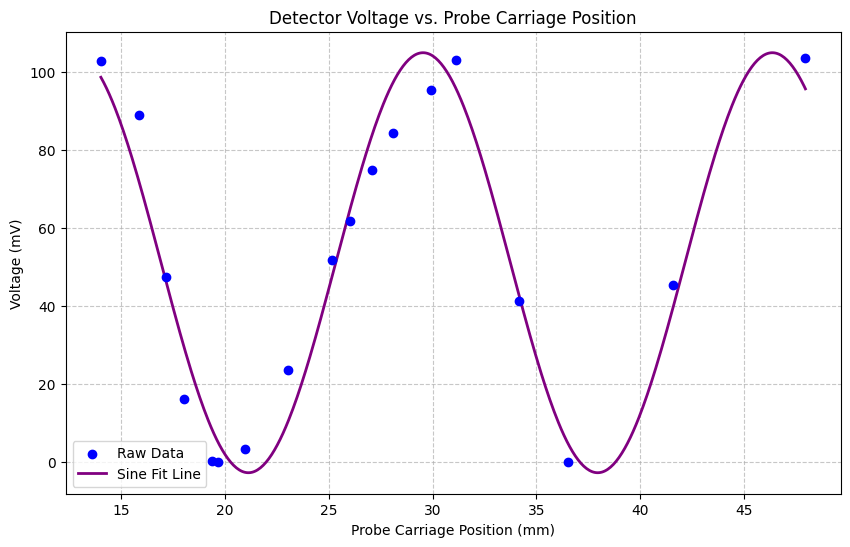

In [186]:
voltage_mV = [102.765, 88.943, 47.468, 16.223, 0.295, 0.013, 3.379, 23.647, 51.866, 61.935, 74.946, 84.392, 95.495, 103.229, 41.229, 0.014, 45.518, 103.56]
dist_mm = [14.03, 15.85, 17.15, 18.01, 19.36, 19.66, 20.96, 23.02, 25.18, 26.04, 27.07, 28.07, 29.926, 31.15, 34.18, 36.50, 41.57, 47.95]

voltage_mV = np.array(voltage_mV)
dist_mm = np.array(dist_mm)

# Equation: V(x) = A * sin(B * x + C) + D
def sine_model(x, A, B, C, D):
    return A * np.sin(B * x + C) + D

# Initial guesses: Amplitude=50, B=0.37 (from ~17mm period), Phase=0, Offset=50
initial_guess = [50, 0.37, 0, 50]
params, covariance = curve_fit(sine_model, dist_mm, voltage_mV, p0=initial_guess)

A, B, C, D = params
dist_fit = np.pi / abs(B)

print(f"--- Fit Parameters ---")
print(f"Amplitude (A): {A:.3f} mV")
print(f"Wavenumber (B): {B:.3f} rad/mm")
print(f"Phase (C):     {C:.3f} rad")
print(f"Offset (D):    {D:.3f} mV")

x_plot = np.linspace(dist_mm.min(), dist_mm.max(), 500)
y_plot = sine_model(x_plot, *params)

plt.figure(figsize=(10, 6))
plt.scatter(dist_mm, voltage_mV, color='blue', label='Raw Data', zorder=5)
plt.plot(x_plot, y_plot, label='Sine Fit Line', color='purple', linewidth=2)
plt.title("Detector Voltage vs. Probe Carriage Position")
plt.xlabel("Probe Carriage Position (mm)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- Sees like fluctuation in the probe output signal decreases with ouptut voltage - this makes sense since noise scales with signal amplitude (constant noise-to-signal ratio)
-  The signal looks a little lopsided, seems to be biased towards the rising edge - minima are not spaced evenly between maxima points
- Attempting to fix by adjusting the micrometer again, this time increasing it to $4.173$ mm
- Also realized there's no need to collect that many data points at this point in time, really only just need the maximas and minimas


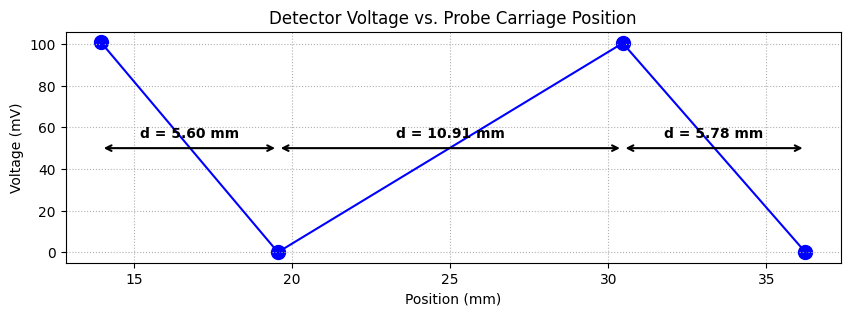

In [187]:
voltage_mV = (100.865, 0.014, 100.429, 0.016)
position_mm = (13.95, 19.55, 30.46, 36.24)
diff_mm = np.diff(position_mm)

plt.figure(figsize=(10, 3))
for i, diff in enumerate(diff_mm):
    plt.annotate('', xy=(position_mm[i], 50), xytext=(position_mm[i+1], 50),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
    plt.text((position_mm[i] + position_mm[i+1])/2, 55, f'd = {diff_mm[i]:.2f} mm', 
         ha='center', color='black', fontweight='bold')
plt.scatter(position_mm, voltage_mV, color='blue', s=100)
plt.plot(position_mm, voltage_mV, color='blue')
plt.title("Detector Voltage vs. Probe Carriage Position")
plt.xlabel("Position (mm)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle=':')
plt.show()



- Increasing the micrometer a bit more to $4.185$ mm

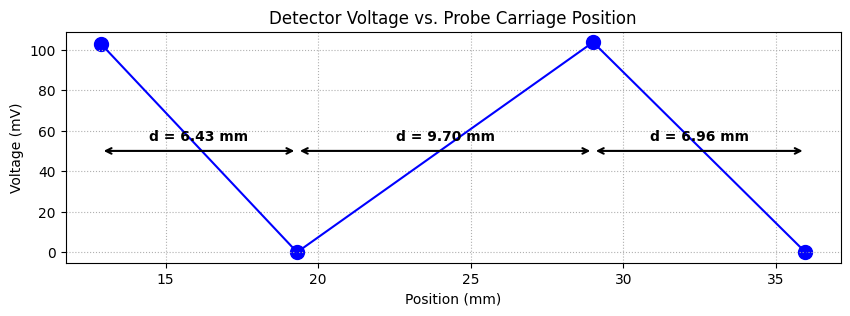

In [260]:
voltage_mV = [102.865, 0.014, 103.629, 0.016]
position_mm = [12.88, 19.31, 29.01, 35.97]
diff_mm = np.diff(position_mm)

plt.figure(figsize=(10, 3))
for i, diff in enumerate(diff_mm):
    plt.annotate('', xy=(position_mm[i], 50), xytext=(position_mm[i+1], 50),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
    plt.text((position_mm[i] + position_mm[i+1])/2, 55, f'd = {diff_mm[i]:.2f} mm', 
         ha='center', color='black', fontweight='bold')
plt.scatter(position_mm, voltage_mV, color='blue', s=100)
plt.plot(position_mm, voltage_mV, color='blue')
plt.title("Detector Voltage vs. Probe Carriage Position")
plt.xlabel("Position (mm)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle=':')
plt.show()

- Trying again with micrometer $4.195$ mm

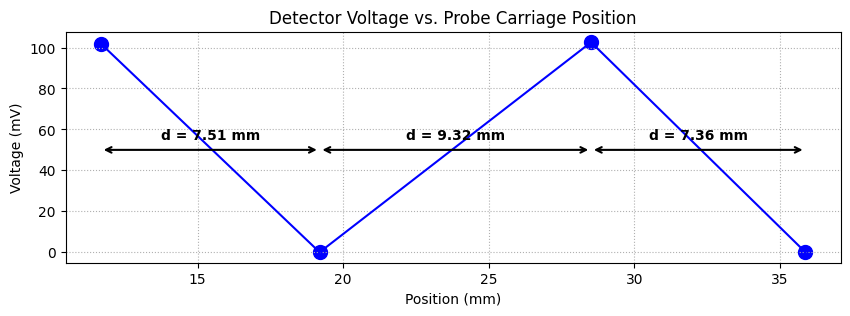

In [189]:
voltage_mV = [101.865, 0.014, 102.579, 0.016]
position_mm = [11.68, 19.19, 28.51, 35.87]
diff_mm = np.diff(position_mm)

plt.figure(figsize=(10, 3))
for i, diff in enumerate(diff_mm):
    plt.annotate('', xy=(position_mm[i], 50), xytext=(position_mm[i+1], 50),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
    plt.text((position_mm[i] + position_mm[i+1])/2, 55, f'd = {diff_mm[i]:.2f} mm', 
         ha='center', color='black', fontweight='bold')
plt.scatter(position_mm, voltage_mV, color='blue', s=100)
plt.plot(position_mm, voltage_mV, color='blue')
plt.title("Detector Voltage vs. Probe Carriage Position")
plt.xlabel("Position (mm)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle=':')
plt.show()



- Hopefully this is the last time, setting micrometer to $4.205$ mm

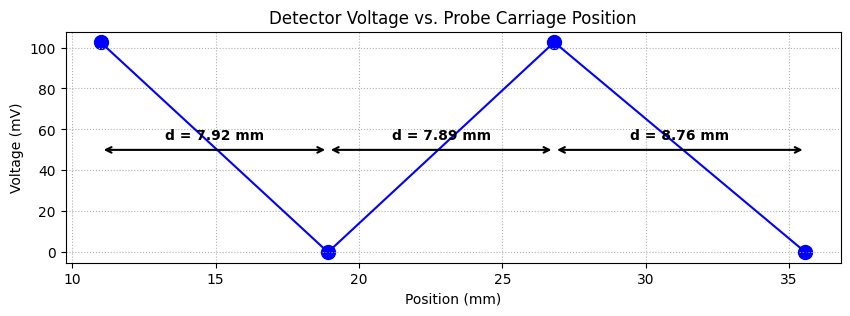

In [190]:
voltage_mV = [102.462, 0.014, 102.579, 0.016]
position_mm = [11.00, 18.92, 26.81, 35.57]
diff_mm = np.diff(position_mm)

plt.figure(figsize=(10, 3))
for i, diff in enumerate(diff_mm):
    plt.annotate('', xy=(position_mm[i], 50), xytext=(position_mm[i+1], 50),
             arrowprops=dict(arrowstyle='<->', lw=1.5))
    plt.text((position_mm[i] + position_mm[i+1])/2, 55, f'd = {diff_mm[i]:.2f} mm', 
         ha='center', color='black', fontweight='bold')
plt.scatter(position_mm, voltage_mV, color='blue', s=100)
plt.plot(position_mm, voltage_mV, color='blue')
plt.title("Detector Voltage vs. Probe Carriage Position")
plt.xlabel("Position (mm)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle=':')
plt.show()

- Okay this looks a lot better, I think there are a few more things I can finetune with the micrometer and the tuning plunger, but in interest of time, I'll move onto the next part of the lab
- One thing that isn't consistent with the calibration sheet is the signal amplitude 
    - @8.005V, 0.043A and micrometer at 4.205mm, the calibration sheet shows maxima peaks closer to 300mV 
    - The highest I ever saw was around ~102.34mV
    - This attenuation can be caused by a variety of factors and most likely can be tuned by adjusting the depth of the probe in the waveguide. I didn't want to mess with the calibration I had already done up to this point, so opted to keep the proe depth as is
    - It seems like the amplitude doesn't matter as much as being able to differentiate between maximas and minimas to calculate the wavelengths

- To summarize, the spacing between sucessive minimas and successive maximas is ~$16.68 \pm 0.2$ mm
- And the spacing between minima and maxima is ~$8.34 \pm 0.5$ mm

#### 2.3 Task 1 - Determination of Cut-off Wavelength
##### 2.3.1 Guide wavelength 

- To find the guided wavelength $\lambda_g$, I want to determine the distance betwen successive maxima/minima with reflecting sheet fixed in place and removing the termination plate
- This is fairly similar to the calibration step in the previous step, but with noticeably lower amplitudes 
- Just so we're capturing the general shape of the signal as well, I'll aim to record 2 extra data points between every peak/trough pair
- And if I want to capture 4 complete cycles, this is $6 * 4 = 24$ points


   Voltage (mV)  Probe Carriage Position (mm)
0        14.854                         23.29
1        46.377                         31.84
2        14.220                         39.93
3        46.057                         47.43
4        14.604                         56.63
5        46.417                         64.79
6        14.519                         73.20


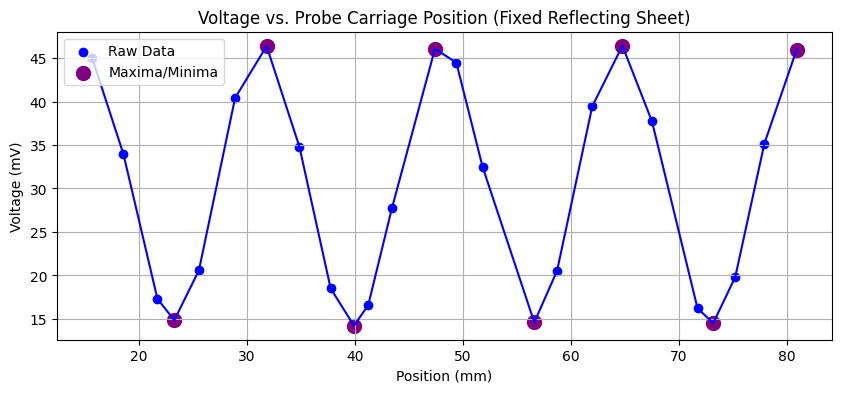

In [191]:
voltage_mV = np.array([45.018, 33.946, 17.306, 14.854, 20.587, 40.407, 46.377, 34.783, 18.5077, 14.22, 16.592, 27.761, 46.057, 44.473, 32.490, 14.604, 20.543, 39.450, 46.417, 37.713, 16.213, 14.519, 19.813, 35.167, 45.977])
dist_mm = np.array([15.68, 18.58, 21.73, 23.29, 25.57, 28.92, 31.84, 34.88, 37.77, 39.93, 41.25, 43.45, 47.43, 49.41, 51.84, 56.63, 58.74, 62.00, 64.79, 67.53, 71.75, 73.20, 75.24, 77.94, 80.93])
maxima_minima_positions = [3, 6, 9, 12, 15, 18, 21, 24]
voltage_mV_subset = voltage_mV[maxima_minima_positions]
dist_mm_subset = dist_mm[maxima_minima_positions]

maximas_minimas = {'Voltage (mV)': voltage_mV_subset, 'Probe Carriage Position (mm)': dist_mm_subset}
df = pd.DataFrame(maximas_minimas)
print(df.head(7))

plt.figure(figsize=(10,4))
plt.title('Voltage vs. Probe Carriage Position (Fixed Reflecting Sheet)')
plt.scatter(dist_mm, voltage_mV, color='blue', label='Raw Data')
plt.plot(dist_mm, voltage_mV, color='blue')
plt.scatter(dist_mm_subset, voltage_mV_subset, color='purple', label='Maxima/Minima', s=100)
plt.xlabel("Position (mm)")
plt.ylabel("Voltage (mV)")
plt.grid()
plt.legend(loc='upper left') 
plt.show()

In [ ]:
# Find distance between minimas and maximas
lambda_g = 4 * np.mean(np.diff(dist_mm_subset)) # 1 period = 4 * distance between node and antinode
print(f"Calculated guide wavelength: {lambda_g:.03f} mm")

Calculated guide wavelength: 40.120 mm


- So the guide wavelength is approximately:

\begin{align*}
\boxed{\lambda_g = 40.120 \pm 0.23 mm} \tag{2.3.1.1}
\end{align*}

##### 2.3.2 Free space wavelength

- Next, in order to find the freespace wavelength $\lambda_0$, we need to keep the probe carriage fixed and slide the aluminum reflecting sheet backwards 
- For all measurements, I have the probe carriage sitting at $0$ mm which corresponds to a base readout of $42.317$ mV
- Realized that I don't need to take so many datapoints, only need to find the positions of the maximas

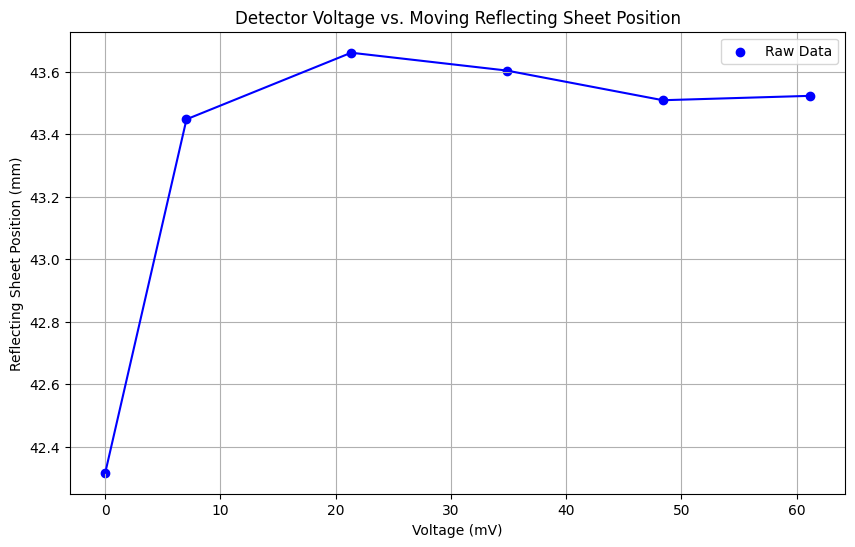

In [214]:
sheet_voltage_mV = [42.317, 43.448, 43.661, 43.604, 43.509, 43.523]
sheet_dist_mm = [0, 7.05, 21.34, 34.83, 48.39, 61.14]

plt.figure(figsize=(10, 6))
plt.title("Detector Voltage vs. Moving Reflecting Sheet Position")
plt.scatter(sheet_dist_mm, sheet_voltage_mV, color='blue', label='Raw Data')
plt.plot(sheet_dist_mm, sheet_voltage_mV, color='blue')
plt.xlabel('Voltage (mV)')
plt.ylabel('Reflecting Sheet Position (mm)')
plt.grid()
plt.legend()
plt.show()

In [ ]:
lambda_0 = 2 * np.mean(np.diff(sheet_dist_mm))
print(f'Free space wavelength: {lambda_0:.03f} mm')

Free space wavelength: 29.325 mm


- So the free space wavelength is approximately:

\begin{align*}
\boxed{\lambda_0 = 29.325 \pm 0.35 mm} \tag{2.3.2.1}
\end{align*}

##### 2.3.3 Cut-off wavelength

- There's 2 methods to calculate the cut-off wavelength $\lambda_c$
- Rearranging equation 1.1.2 and 1.1.3, we see that we could either solve in 2 ways
- Method 1 relies on the experimentally determined guide and free-space wavelengths and method 2 relies on the dimensions of the waveguide itself
- Method 1:

\begin{align*}
\frac{1}{\lambda_c^2} = \left(\frac{1}{\lambda_0^2} - \frac{1}{\lambda_g^2}\right) \tag{2.3.3.1}
\end{align*}

- Method 2:

\begin{align*}
\frac{1}{\lambda_c^2} = \left(\frac{n}{2b}\right)^2 + \left(\frac{m}{2a}\right)^2 \tag{2.3.3.2}
\end{align*}

- Here we can take $n=0$ and $m=1$, which means only dimension $a$ (the guide width) is relevant
- Using a pair of analog calipers, I measured the waveguide cross-section length to be $a = 22.5 \pm 0.1$ mm  

In [195]:
# Method 1
lambda_c1 = (((1/lambda_0) ** 2) - ((1/lambda_g) ** 2)) ** (-1/2)
print(f"Cut-off wavelength (method 1): {lambda_c1:.03f} mm")

# Method 2
lambda_c2 = ((1 / (2 * 22.5)) ** 2) ** (-1/2)
print(f"Cut-off wavelength (method 2): {lambda_c2:.03f} mm")


Cut-off wavelength (method 1): 42.970 mm
Cut-off wavelength (method 2): 45.000 mm


- So, the cut-off wavelength $\lambda_c$ determined using method 1 (experimentally) is:

\begin{align*}
\boxed{\lambda_c = 42.970 mm} \tag{2.3.3.1}
\end{align*}

- With an expected cut-off wavelength $\lambda_c$ of:

\begin{align*}
\boxed{\lambda_c = 45.000 mm} \tag{2.3.3.2}
\end{align*}

- The results from our experimentally deduced $\lambda_c$ value (method 1) is fairly similar to the expected value, off by ~3 mm
- The reason for this discrepany is likely due to human measurement error (since all data collection is done manually)
- I did notice some flucations in the probe readings during data collection making it difficult find the exact maxima/minima at times
- I also saw cases where the power supply voltage would creep overtime, starting from 8.005V and slowly increase to 8.985V, which affected the overall signal amplitude 
- One thing that I would do if I have time next lab session would be to propagate the uncertainties from $a$, $\lambda_0$, and $\lambda_g$ to understand if this error is within the expected bounds 

#### 2.4 Task 2 - Impedance Measurement

##### 2.4.1 Determine short-circuited VSWR
- To find the VSWR (voltage standing wave ratio), we probably want to average across off the maximas and minimas in a dataset to determine $V_{max}$ and $V_{min}$
- We know that the standing wave is the ratio between $V_{max}$ and $V_{min}$

   Voltage (mV)  Probe Carriage Position (mm)
0       102.765                         12.03
1        88.943                         13.85
2        47.468                         17.15
3        16.223                         18.01
4         0.105                         19.36
5         0.113                         19.66
6         3.379                         20.96

Experimentally determined VSWR: 1334.284


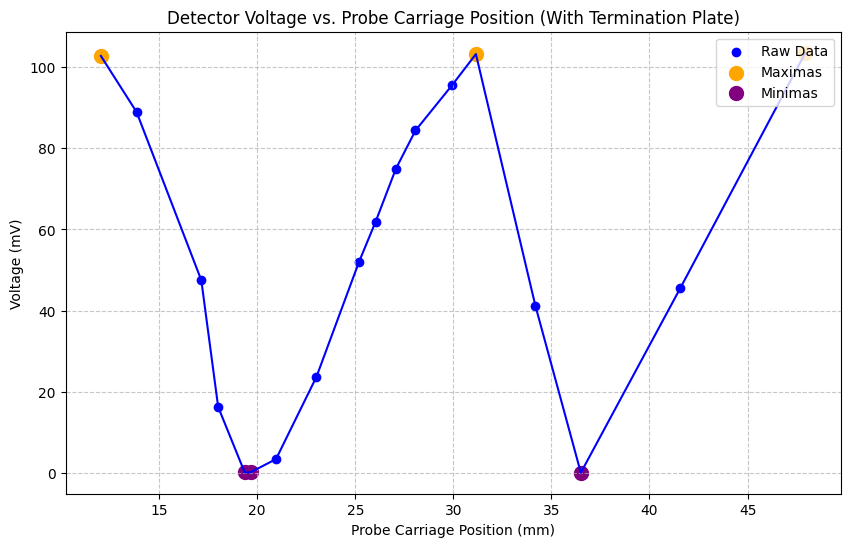

In [ ]:
voltage_mV = [102.765, 88.943, 47.468, 16.223, 0.105, 0.113, 3.379, 23.647, 51.866, 61.935, 74.946, 84.392, 95.495, 103.229, 41.229, 0.014, 45.518, 103.56]
dist_mm = [12.03, 13.85, 17.15, 18.01, 19.36, 19.66, 20.96, 23.02, 25.18, 26.04, 27.07, 28.07, 29.926, 31.15, 34.18, 36.50, 41.57, 47.95]

voltage_mV = np.array(voltage_mV)
dist_mm = np.array(dist_mm)

inline_data = {'Voltage (mV)': voltage_mV, 'Probe Carriage Position (mm)': dist_mm}
df = pd.DataFrame(inline_data)
print(df.head(7))

max_idx = np.where(voltage_mV > 101)[0]
min_idx = np.where(voltage_mV < 1)[0]
max_positions = dist_mm[max_idx]
max_voltages = voltage_mV[max_idx]
min_positions = dist_mm[min_idx]
min_voltages = voltage_mV[min_idx]

avg_maxima = np.mean(max_voltages)
avg_minima = np.mean(min_voltages)
VSWR = avg_maxima / avg_minima
print(f"\r\nExperimentally determined VSWR: {VSWR:.03f}")

plt.figure(figsize=(10, 6))
plt.scatter(dist_mm, voltage_mV, color='blue', label='Raw Data')
plt.plot(dist_mm, voltage_mV, color='blue')
plt.scatter(max_positions, max_voltages, color='orange', label="Maximas", s=100, zorder=1)
plt.scatter(min_positions, min_voltages, color='purple', label="Minimas", s=100, zorder=1)
plt.title("Detector Voltage vs. Probe Carriage Position (With Termination Plate)")
plt.xlabel("Probe Carriage Position (mm)")
plt.ylabel("Voltage (mV)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- So, the VSWR for a short-circuited waveguide is:
\begin{align*}
\boxed{VSWR = 1334.284} \tag{2.4.1.1}
\end{align*}

- This makes sense between it directly corresponds to the reflectivity in the setup, which should approach infinity for a short-circuited system
- 1334.384 is high enough to show this phenomenon 

- In terms of finding the fractional wavelength, we know that the total distance of the waveguide is ~80mm
- We know $\lambda_g = 40.120$ mm which means the expected fractional wavelength between the first maxima and the termination plate should be $\frac{\lambda_g}{4} = 10.03$ mm (refer to lab manual close-loop pipe diagrams)


In [235]:
# Calculate experimental fractional wavelength
frac_wavelength = position_mm[0] / (lambda_g)
print(f'Experimental fractional wavelength: {frac_wavelength:.03f}')

Experimental fractional wavelength: 0.274


- So, the experimental fractional wavelength is very close to the expected value of $0.25$
- The experimental fractional wavelength is:
\begin{align*}
\boxed{\lambda_{\text{fractional}} = 0.274} \tag{2.4.1.2}
\end{align*}



## Session 3: Mar 17th, 2026

#### 3.1 Today's goals
- Complete task 2 questions 2-5 to determine the best method of termination for guided waves
- Wrap up last few measurements to find the normalize impedance 

#### 3.2 Task 2 - Impedance Measurement
##### 3.2.1 Determine VSWR with angled absorption sheet

- This is what my setup now looks like after removing the termination plate and hanging microwave absorbing material at an angle on the reflecting stand to minimize reflections 
- We want to once again measure the VSWR in this configuration and deduce distance of nearest voltage maximum
- Additionally, the lab manual also asks us to find the normalized impedance using the Smith Chart

<img src="../assets/slanted_sheet.jpeg" height="500" alt="slanted sheet setup"/>
<img src="../assets/smith_chart.jpeg" height="500" alt="smith chart"/>

   Voltage (mV)  Probe Carriage Position (mm)
0        15.980                          5.90
1        46.538                         14.86
2        16.010                         25.13
3        46.637                         31.18
4        15.930                         42.38
5        45.450                         48.46
6        15.670                         55.23

Experimentally determined VSWR: 2.902
Experimental fractional wavelength: 0.472


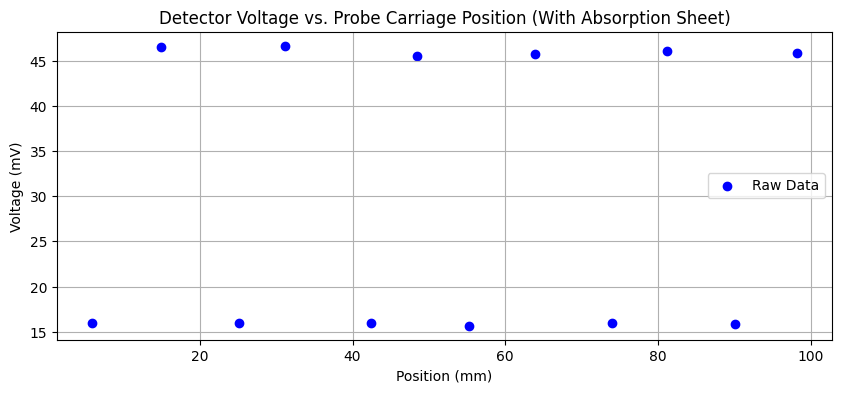

In [253]:
# All maximas
voltage_mV = [15.98, 46.538, 16.01, 46.637, 15.93, 45.45, 15.67, 45.751, 16.02, 46.078, 15.89, 45.789]
dist_mm = [5.9, 14.86, 25.13, 31.18, 42.38, 48.46, 55.23, 63.95, 73.98, 81.17, 90.12, 98.16]

voltage_mV = np.array(voltage_mV)
dist_mm = np.array(dist_mm)

inline_data = {'Voltage (mV)': voltage_mV, 'Probe Carriage Position (mm)': dist_mm}
df = pd.DataFrame(inline_data)
print(df.head(7))

max_idx = np.where(voltage_mV > 45)[0]
min_idx = np.where(voltage_mV < 16)[0]
max_positions = dist_mm[max_idx]
max_voltages = voltage_mV[max_idx]
min_positions = dist_mm[min_idx]
min_voltages = voltage_mV[min_idx]

avg_maxima = np.mean(max_voltages)
avg_minima = np.mean(min_voltages)
VSWR = avg_maxima / avg_minima
print(f"\r\nExperimentally determined VSWR: {VSWR:.03f}")

frac_wavelength = position_mm[1] / (lambda_g)
print(f'Experimental fractional wavelength: {frac_wavelength:.03f}')

plt.figure(figsize=(10, 4))
plt.scatter(dist_mm, voltage_mV, color='blue', label='Raw Data')
plt.title(f"Detector Voltage vs. Probe Carriage Position (With Absorption Sheet)")
plt.grid()
plt.ylabel('Voltage (mV)')
plt.xlabel('Position (mm)')
plt.legend(loc='center right')
plt.show()

- So, the experimental VSWR and fractional wavelength with the absorption sheet are as follows:

\begin{align*}
\boxed{VSWR = 2.902} \tag{3.2.1.1}
\end{align*}

\begin{align*}
\boxed{\lambda_{\text{fractional}} = 0.472} \tag{3.2.1.2}
\end{align*}

- The VSWR is a lot lower with the absorption sheet in place, which makes sense since the absorber reduces reflections significantly
- VSWR isn't exactly 1... I'm guessing this might be because the material is rather worn out and has lost its original efficiency 

- Extending these values to the Smith Chart
- Was a little confused at first, but found some tutorials online and asked TA for help
- The steps I took were roughly as follows:
    - Sketch out the VSWR circle, the circle is centered at (1,0) and must pass through our VWSR value of 2.902
    - Now we have to rotate toward the load, since our fractional wavelength is 0.472, this means we have to start from the $V_min$ point and rotate ccw that many equivalent degrees (0.472 / (0.5 * 360)); the 0.5 comes from the fact that a full rotation around the Smith chart is $0.5\lambda$

- I'm not entirely sure if my process is correct, but through this method, I'm getting a normalized impedance of:

\begin{align*}
\boxed{Z_n = 0.349 + 0.892j} \tag{3.2.1.3}
\end{align*}

 

##### 3.2.2 Determine VSWR with angled absorption sheet and rectangular horn
- Copying the same setup as 3.2.1, but now with a rectangular horn screwed to the end of the waveguide 


   Voltage (mV)  Probe Carriage Position (mm)
0        26.178                         7.380
1        32.158                        17.330
2        26.302                        24.330
3        31.999                        33.880
4        26.259                        40.930
5        32.222                        48.666
6        26.220                        57.590

Experimentally determined VSWR: 1.230
Experimental fractional wavelength: 0.068


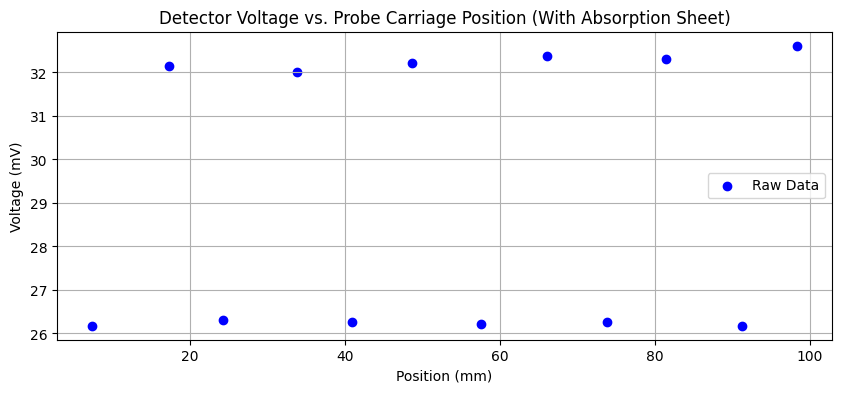

In [ ]:
# All maximas
voltage_mV = [26.178, 32.158, 26.302, 31.999, 26.259, 32.222, 26.22, 32.375, 26.261, 32.302, 26.182, 32.613]
dist_mm = [7.38, 17.33, 24.33, 33.88, 40.93, 48.666, 57.59, 66.15, 73.84, 81.48, 91.23, 98.33]

voltage_mV = np.array(voltage_mV)
dist_mm = np.array(dist_mm)

inline_data = {'Voltage (mV)': voltage_mV, 'Probe Carriage Position (mm)': dist_mm}
df = pd.DataFrame(inline_data)
print(df.head(7))

max_idx = np.where(voltage_mV > 30)[0]
min_idx = np.where(voltage_mV < 27)[0]
max_positions = dist_mm[max_idx]
max_voltages = voltage_mV[max_idx]
min_positions = dist_mm[min_idx]
min_voltages = voltage_mV[min_idx]

avg_maxima = np.mean(max_voltages)
avg_minima = np.mean(min_voltages)
VSWR = avg_maxima / avg_minima
print(f"\r\nExperimentally determined VSWR: {VSWR:.03f}")

frac_wavelength = position_mm[1] / (lambda_g)
print(f'Experimental fractional wavelength: {frac_wavelength:.03f}')

plt.figure(figsize=(10, 4))
plt.scatter(dist_mm, voltage_mV, color='blue', label='Raw Data')
plt.title(f"Detector Voltage vs. Probe Carriage Position (With Absorption Sheet)")
plt.grid()
plt.ylabel('Voltage (mV)')
plt.xlabel('Position (mm)')
plt.legend(loc='center right')
plt.show()

- So, the experimental VSWR and fractional wavelength with the absorption sheet are as follows:

\begin{align*}
\boxed{VSWR = 1.230} \tag{3.2.2.1}
\end{align*}

\begin{align*}
\boxed{\lambda_{\text{fractional}} = 0.06} \tag{3.2.2.2}
\end{align*}

- The VSWR is now getting fairly close to the 1.0 - this is the result of the adding the rectangular horn
    - I suspect this is because the the rectangular horn does a better job of matching the impedance of the guide than free space? 
    - Ahh searched it up and indeed read a few articles talking about how the horn creates a taper/transiiton point in impedance so that power radiated outwards is maximized (rather than reflected back)

- Following the same process mentioned in section 3.2.1, I'm getting a normalized impedance of:

\begin{align*}
\boxed{Z_n = 1.154 + 0.234j} \tag{3.2.2.3}
\end{align*}

- Wait this seems a bit wrong, discussed with TA and lab partner and it seems like the reactance part should be negative (capacitive...)
- OH I think I just rotated the wrong way
- Updated normalized impedance is now closer to:

\begin{align*}
\boxed{Z_n = 1.154 - 0.234j} \tag{3.2.2.3}
\end{align*}

##### 3.2.3 Find termination impedence

- Based on equation 1.1.5, the termination impedance can be found with the parameters we calculated earlier

In [259]:
# Find termination impedance, based on eqn 1.1.5
Z_g = 120 * np.pi * lambda_g / lambda_0
print(f"Termination impedance: {Z_g:.03f} Ohms")

# Multiple guide impedance with each of the normalized impedances in 3.2.1 and 3.2.2
Z_no_horn = Z_g * (0.349 + 0.892j)
Z_with_horn = Z_g * (1.154 - 0.234j)
print(f'Termination impedance with no horn: {Z_no_horn:.03f}')
print(f'Termination impedance with horn: {Z_with_horn:.03f}')

Termination impedance: 515.768 Ohms
Termination impedance with no horn: 180.003+460.065j
Termination impedance with horn: 595.196-120.690j


##### 3.2.4 Choose best termination method

-  Looking at the two methods of termination: 1) open termination at end of waveguide vs. 2) termination with a rectangular horn, it's clear that the horn is the better option
- Reason number one is because the impedance is better matched = causes less reflections in signal and power being lost
    - This can be seen by simply comparing the real parts of the terminaion impedance found in section 3.2.3

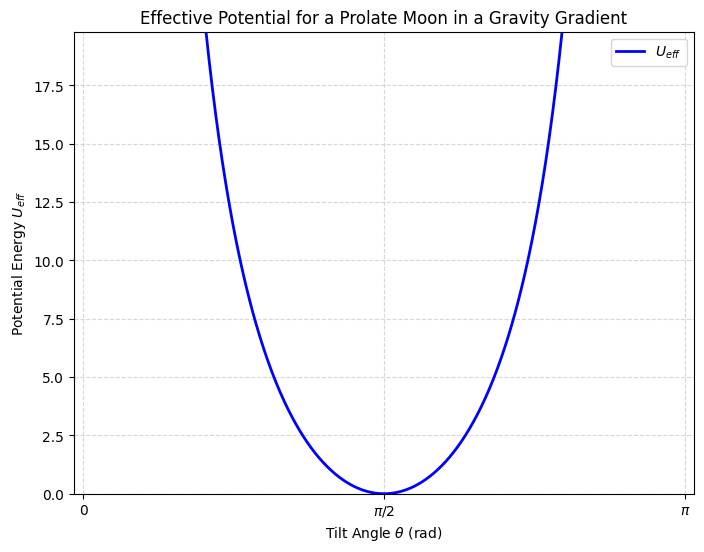

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1.0
b = 1.5      # Prolate: b > a
w = 0.5      # Initial azimuthal velocity
alpha = 2.0  # Strength of gravity gradient
delta = 0.2  # Small initial perturbation

# Derived L3 (Spin angular momentum)
L_3 = (a**2 + b**2) * w / delta

theta = np.linspace(0.1, np.pi - 0.1, 1000)

centrifugal_term = (L_3**2 * np.cos(theta)**2) / (2 * (a**2 + b**2) * np.sin(theta)**2)
gravity_term = alpha * (b**2 - a**2) * np.cos(theta)**2
U_eff = centrifugal_term + gravity_term

plt.figure(figsize=(8, 6))
plt.plot(theta, U_eff, label='$U_{eff}$', color='blue', linewidth=2)

# Aesthetics
plt.ylim(0, np.max(gravity_term) * 8) # Zoom in to see the well
# Set manual positions and labels
pi = np.pi
plt.xticks([0, pi/2, pi], 
              labels=[r'0', r'$\pi/2$', r'$\pi$'])

plt.xlabel(r'Tilt Angle $\theta$ (rad)')
plt.ylabel(r'Potential Energy $U_{eff}$')
plt.title('Effective Potential for a Prolate Moon in a Gravity Gradient')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()